# Digit Recognition App — From Scratch to CNN

Welcome to the **Digit Recognition App** tutorial! In this end-to-end project, we will teach a computer how to **read handwritten numbers (0–9)** using real neural network math.

### What You Will Build
This notebook is split into **four major sections**, each building on the previous:

| Section | What You Learn |
|---------|----------------|
| **1 — Data** | Load & visualize the MNIST dataset |
| **2 — NumPy MLP** | Build a neural network from pure math (no framework!) |
| **3 — PyTorch MLP → CNN** | Use PyTorch to do the same thing faster, then upgrade to CNNs |
| **4 — RNN Bonus** | Understand sequence models with a simple RNN example |

Then we cap the project with **model saving**, **test-set evaluation**, a **hyperparameter experiment**, and an **interactive drawing widget** so you can actually *draw a digit and see the model predict it in real time!*

### Dataset: MNIST
We will use the famous **MNIST dataset** — 60,000 training images and 10,000 test images of handwritten digits, each exactly **28 × 28 pixels** in grayscale.

> **Key vocabulary:** A **pixel** is the smallest unit of a digital image. Each pixel in MNIST has a brightness value between 0 (black) and 255 (white). Our job is to turn these grids of numbers into correct digit predictions.

---
## Section 1: Loading and Visualizing the Data

Before building any AI, we must **understand our data**. This section downloads MNIST and gives us a visual feel for what the network will be learning from.

### Library Overview
| Library | Purpose |
|---------|----------|
| `torch` / `torchvision` | Download MNIST; later we use PyTorch for training |
| `matplotlib` | Draw charts and images |
| `numpy` | Fast math arrays — the backbone of Section 2 |

In [1]:
# Import deep learning frameworks
import torch
import torchvision
from torchvision import transforms

# Import visualization and math libraries
import matplotlib.pyplot as plt
import numpy as np

print("All libraries successfully imported!")

All libraries successfully imported!


### Downloading MNIST (Training + Test Splits)

An image is just a grid of numbers. Every MNIST image is **28 × 28 = 784 numbers**, where each number represents how bright that pixel is.

We download **two splits**:
- **Training set (60,000 images):** Used to teach the network.
- **Test set (10,000 images):** Used *after* training to measure how well the network generalises to digits it has **never seen before**. This is the true measure of success.

`transforms.ToTensor()` converts raw images into PyTorch tensors and automatically rescales pixel values from [0, 255] to [0.0, 1.0].

In [2]:
# transforms.ToTensor() converts images to PyTorch tensors AND normalises to [0, 1]
transform = transforms.ToTensor()

# Download the TRAINING set (train=True) — 60,000 images used to learn
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

# Download the TEST set (train=False) — 10,000 images NEVER seen during training
# This is how we honestly measure if the model has truly learned, not just memorised
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

print(f"Training images: {len(train_dataset):,}")
print(f"Test images    : {len(test_dataset):,}")

Training images: 60,000
Test images    : 10,000


### Visualizing the Digits

Numbers alone are hard to reason about. Let's actually **see** the images our network will learn from. Each image is stored as a tensor of shape `(1, 28, 28)` — that means 1 color channel (grayscale), 28 rows, 28 columns.

> **Why `.squeeze()`?** Matplotlib's `imshow` expects a 2D array `(Height, Width)` for grayscale images. Our tensor has shape `(1, 28, 28)`. `.squeeze()` removes that redundant `1` dimension, giving us `(28, 28)` — exactly what Matplotlib wants.

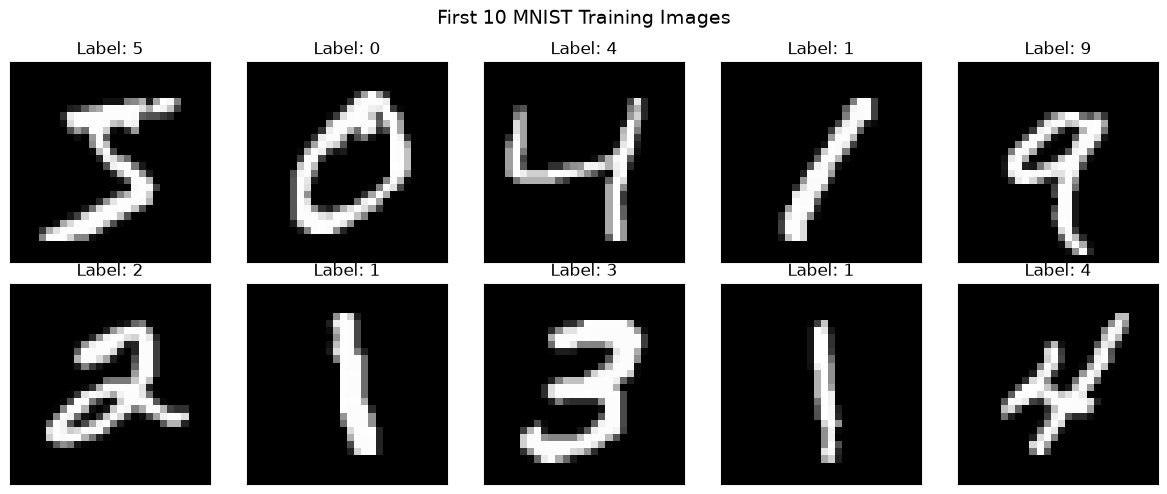

In [3]:
# Create a blank figure (canvas) with a defined size
fig = plt.figure(figsize=(12, 5))

# Loop through the first 10 images in our training dataset
for i in range(10):
    # Each item in the dataset is a (image_tensor, label) tuple
    image, label = train_dataset[i]
    
    # Arrange 10 plots in a 2-row × 5-column grid
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    
    # image has shape (1, 28, 28). .squeeze() makes it (28, 28) for Matplotlib
    ax.imshow(image.squeeze(), cmap='gray')
    
    # Display the ground-truth label as the plot title
    ax.set_title(f"Label: {label}")

plt.suptitle("First 10 MNIST Training Images", fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 2: Building a Neural Network from Scratch (Pure NumPy)

Before we use a framework, we will build **every single math operation by hand**. This section demystifies how AI truly works — no magic, just matrix multiplication and calculus.

### Architecture: Multi-Layer Perceptron (MLP)

Our network has three layers:

```
INPUT LAYER       HIDDEN LAYER      OUTPUT LAYER
784 neurons  →→→  128 neurons  →→→  10 neurons
(one per pixel)   (pattern finder)  (digit 0–9 probability)
```

Each arrow represents a **weight matrix**. The network *learns* by adjusting these weights so that the output probabilities become more accurate over time.

### Data Preparation

Our 28 × 28 images must be flattened into **1D vectors of 784 numbers** before feeding them into the network. We also apply two transformations:

1. **Flattening** — reshape `(60000, 28, 28)` to `(60000, 784)` 
2. **Normalisation** — divide by 255 so all pixel values are in [0.0, 1.0], which makes training stable
3. **One-Hot Encoding** — convert a label like `3` into `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]` so we can compute a meaningful error against each output neuron

In [4]:
# --- Flatten and normalise training images ---
# .data gives us raw pixel integers; .numpy() converts to NumPy
# reshape(-1, 784) flattens 28x28 into 784; / 255.0 normalises to [0, 1]
X_train = train_dataset.data.numpy().reshape(-1, 28*28) / 255.0

# Ground-truth labels as integers (0 through 9)
Y_train_raw = train_dataset.targets.numpy()

# One-Hot Encoding
# Example: label 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
def one_hot_encode(Y, num_classes=10):
    one_hot = np.zeros((Y.size, num_classes))  # Start with all zeros
    one_hot[np.arange(Y.size), Y] = 1          # Set the correct class to 1
    return one_hot

Y_train = one_hot_encode(Y_train_raw)

print(f"Flattened Image Shape: {X_train.shape}")
print(f"One-Hot Label Shape  : {Y_train.shape}")

Flattened Image Shape: (60000, 784)
One-Hot Label Shape  : (60000, 10)


### Step 1: Initialising the Weights

Think of weights as the **dials on a radio** — at the start they are random noise. Training is the process of turning those dials until the music comes in clearly.

**Why multiply by 0.01?**  
If we initialise weights with large random values, the neurons saturate early (all output the same thing) and learning stalls. Multiplying by 0.01 keeps the initial signals small, preventing this **vanishing/exploding gradient problem** from the very first step.

**Why use `np.random.seed(42)`?**  
Random initialisation means results change every run. A fixed seed makes results reproducible — important for debugging and teaching. Note: the `lr=0.5` used later only works stably under this specific seed and normalised inputs. If you remove the seed and use a different run, you may see oscillating loss — see the hyperparameter experiment in Section 5.

In [5]:
# Fix the random seed for reproducibility
np.random.seed(42)

# W1: weight matrix between Input (784) and Hidden (128) layers
# Shape (784, 128) because each of 784 input pixels connects to 128 hidden neurons
W1 = np.random.randn(784, 128) * 0.01  # Small initial values prevent gradient explosion
b1 = np.zeros((1, 128))                # Biases start at zero — neutral starting point

# W2: weight matrix between Hidden (128) and Output (10) layers
W2 = np.random.randn(128, 10) * 0.01   # 128 hidden neurons → 10 output classes
b2 = np.zeros((1, 10))                 # One bias per output class

print("Weights and Biases Initialized!")

Weights and Biases Initialized!


### Step 2: Forward Propagation — Making a Guess

In the forward pass, data flows **left to right** through the network:

```
Pixels  →  [W1, b1]  →  ReLU  →  [W2, b2]  →  Softmax  →  Probabilities
```

Each step is a simple formula:
- **Z = X · W + b** — a weighted sum (linear transformation)
- **A = activation(Z)** — a non-linear transformation that lets the network learn complex patterns

#### Activation Functions Explained

| Function | Formula | Purpose |
|----------|---------|----------|
| **ReLU** | `max(0, Z)` | Turns negative values to 0. Introduces non-linearity so the network can model curves, not just lines. |
| **Softmax** | `exp(Zi) / Σ exp(Zj)` | Converts 10 raw scores into 10 **probabilities** that sum to 1.0 (100%). |

> **Numerical stability tip:** We subtract `max(Z)` before calling `exp()` in Softmax. This prevents numbers like `exp(1000)` from causing overflow (infinity), which would crash the math. The result is mathematically identical but safe.

In [6]:
def relu(Z):
    """ReLU: pass positive values through, clamp negatives to zero."""
    return np.maximum(0, Z)  # Element-wise max(0, x)

def softmax(Z):
    """Convert raw scores to probabilities that sum to 1."""
    # Subtract max for numerical stability (prevents exp() overflow)
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)  # Normalise to [0, 1]

def forward_propagation(X, W1, b1, W2, b2):
    """One full forward pass through the network."""
    # --- Hidden Layer ---
    Z1 = np.dot(X, W1) + b1   # Linear: (m, 784) · (784, 128) = (m, 128)
    A1 = relu(Z1)              # Non-linear activation
    
    # --- Output Layer ---
    Z2 = np.dot(A1, W2) + b2  # Linear: (m, 128) · (128, 10) = (m, 10)
    A2 = softmax(Z2)           # Convert to probabilities
    
    return Z1, A1, Z2, A2     # Return all intermediates — needed for backprop

### Step 3: The Math of Learning — Loss, Gradients, and the Chain Rule

This is the **most important concept** in deep learning. Read it carefully.

#### What is Loss?

The **loss** (also called cost or error) measures how wrong the network is. We use **Cross-Entropy Loss**, which is ideal for classification:

$$L = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=0}^{9} Y_{ik} \cdot \log(A2_{ik})$$

- `Y` = the true one-hot label (e.g., `[0,0,0,1,0,0,0,0,0,0]` for digit 3)
- `A2` = the network's predicted probabilities (e.g., `[0.02, 0.01, 0.05, 0.80, ...]`)
- The loss is **large** when the predicted probability for the correct class is low, and **small** when it is close to 1.0.

#### What is the Gradient of the Loss?

The gradient of the cross-entropy loss with respect to the Softmax output has a remarkably clean closed-form:

$$\frac{\partial L}{\partial Z_2} = A_2 - Y$$

This is `dZ2` in our code: the difference between what the network predicted and what the correct answer actually was. **The bigger the mistake, the bigger the gradient, and the bigger the weight update.**

#### The Chain Rule — How Gradients Flow Backward

To update the weights in the **hidden layer** (W1), we must trace the error back through the output layer first. This is the **Chain Rule** from calculus:

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial W_1}$$

In code:
```python
dZ2 = A2 - Y                          # ∂L/∂Z2  (loss gradient at output)
dA1 = np.dot(dZ2, W2.T)               # ∂L/∂A1  (gradient flows back through W2)
dZ1 = dA1 * relu_derivative(Z1)       # ∂L/∂Z1  (gradient through ReLU gate)
dW1 = (1/m) * np.dot(X.T, dZ1)        # ∂L/∂W1  (final gradient for W1 update)
```

Every line of the `backward_propagation` function below directly corresponds to one of these calculus steps.

In [7]:
def relu_derivative(Z):
    """Gradient of ReLU: 1 where Z > 0, else 0 (a binary gate)."""
    return Z > 0  # Returns True/False, which NumPy treats as 1/0

def backward_propagation(X, Y, Z1, A1, A2, W2):
    """Compute gradients using the chain rule (backpropagation)."""
    m = X.shape[0]  # Number of training examples (used to average the gradients)
    
    # ─── Output Layer Gradients ───
    # dZ2 = ∂L/∂Z2 = A2 - Y  (gradient of cross-entropy loss w.r.t. softmax input)
    # This is the clean closed-form result of combining softmax + cross-entropy derivatives
    dZ2 = A2 - Y
    dW2 = (1 / m) * np.dot(A1.T, dZ2)       # ∂L/∂W2 — averaged over all examples
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)  # ∂L/∂b2
    
    # ─── Hidden Layer Gradients (Chain Rule applied) ───
    # dZ1 = (dZ2 · W2ᵀ) * ReLU'(Z1)
    # Step 1: dot(dZ2, W2.T) propagates the error BACK through W2 to find ∂L/∂A1
    # Step 2: multiplying by relu_derivative(Z1) gates the gradient through ReLU
    #         (neurons that were 'off' during forward pass get 0 gradient — no update)
    dZ1 = np.dot(dZ2, W2.T) * relu_derivative(Z1)
    dW1 = (1 / m) * np.dot(X.T, dZ1)        # ∂L/∂W1
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)  # ∂L/∂b1
    
    return dW1, db1, dW2, db2

### Step 4: The Training Loop (Gradient Descent)

Now we tie it all together. Each **epoch** is one complete pass through all 60,000 training images:

1. **Forward pass** — make predictions
2. **Backward pass** — compute how wrong we were and in which direction
3. **Weight update** — nudge the weights a small amount in the direction that reduces loss:

$$W \leftarrow W - \alpha \cdot \frac{\partial L}{\partial W}$$

where `α` (alpha) is the **learning rate** — it controls the size of each nudge. This algorithm is called **Gradient Descent**.

In [8]:
# Learning rate controls how big each weight update step is.
# 0.5 is high for full-batch gradient descent — it works HERE because of the fixed
# seed (42) and normalised inputs. Try 0.1 in the hyperparameter experiment below!
learning_rate = 0.5
epochs = 100

def get_accuracy(predictions, Y_true):
    """Calculate what percentage of predictions match the true labels."""
    return np.mean(predictions == Y_true) * 100

# ─── Training Loop ───
for i in range(epochs):
    # Step 1: Forward pass — get predictions
    Z1, A1, Z2, A2 = forward_propagation(X_train, W1, b1, W2, b2)
    
    # Step 2: Backward pass — compute gradients (how much to change each weight)
    dW1, db1, dW2, db2 = backward_propagation(X_train, Y_train, Z1, A1, A2, W2)
    
    # Step 3: Gradient descent update — move weights in the direction of lower loss
    W1 = W1 - learning_rate * dW1  # Subtract gradient × learning_rate
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    # Print progress every 20 epochs so we can watch learning happen
    if i % 20 == 0:
        predictions = np.argmax(A2, axis=1)  # Pick the class with highest probability
        accuracy = get_accuracy(predictions, Y_train_raw)
        print(f"Epoch {i:>3}: Training Accuracy = {accuracy:.2f}%")

print("\nNumPy Training Complete! The network has learned to read digits from scratch.")

Epoch   0: Training Accuracy = 12.48%
Epoch  20: Training Accuracy = 77.25%
Epoch  40: Training Accuracy = 84.56%
Epoch  60: Training Accuracy = 86.70%
Epoch  80: Training Accuracy = 89.53%

NumPy Training Complete! The network has learned to read digits from scratch.


---
## Section 3: The Modern Way — PyTorch MLP → CNN

Writing backpropagation from scratch is powerful for learning, but impractical at scale. **PyTorch** automates the calculus using a system called **Autograd** — every operation it performs is recorded, so it can automatically compute gradients with a single `loss.backward()` call.

### Why Batches?

In Section 2 we fed all 60,000 images at once (full-batch gradient descent). PyTorch instead uses **mini-batches** (e.g., 64 images at a time):

| Method | Batch Size | Speed | Stability |
|--------|------------|-------|-----------|
| Full-batch GD | All data | Slow | Very stable |
| Mini-batch SGD | 32–512 | Fast | Some noise |
| Stochastic GD | 1 image | Very fast | Noisy |

Mini-batches give us the **best of both worlds**: fast enough to process large datasets, stable enough to converge reliably.

In [9]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# DataLoader wraps the dataset and automatically:
#   - splits it into batches of `batch_size` images
#   - shuffles the order each epoch (prevents the network learning order instead of digits)
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# We also create a test loader (no shuffle needed — we just want to measure accuracy)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches : {len(train_loader)} × {batch_size} images")
print(f"Test batches     : {len(test_loader)} × {batch_size} images")

Training batches : 938 × 64 images
Test batches     : 157 × 64 images


### Building the PyTorch MLP

In PyTorch, we define networks as **classes** that inherit from `nn.Module`. The framework then:
- Automatically tracks all parameters (W1, b1, W2, b2) in the background
- Records every operation in a computation graph for automatic differentiation

Notice how `nn.Linear(784, 128)` replaces all of the weight initialisation code from Section 2!

In [10]:
class PyTorchMLP(nn.Module):
    def __init__(self):
        super(PyTorchMLP, self).__init__()
        # nn.Linear(in, out) is equivalent to our W and b matrices combined
        self.layer1 = nn.Linear(28 * 28, 128)  # Replaces W1 (784×128) and b1
        self.relu   = nn.ReLU()                 # Same as our relu() function
        self.layer2 = nn.Linear(128, 10)        # Replaces W2 (128×10) and b2
        
    def forward(self, x):
        # Flatten the (batch, 1, 28, 28) tensor into (batch, 784)
        x = x.view(-1, 28 * 28)  # -1 means 'infer this dimension automatically'
        x = self.layer1(x)        # Linear transform: Z1 = X·W1 + b1
        x = self.relu(x)          # Activation: A1 = ReLU(Z1)
        x = self.layer2(x)        # Linear transform: Z2 = A1·W2 + b2
        # Note: NO Softmax here. PyTorch's CrossEntropyLoss applies it internally.
        # This is more numerically stable than applying Softmax separately.
        return x

model = PyTorchMLP()
print(model)

PyTorchMLP(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


### Training the PyTorch MLP

The training loop in PyTorch follows **five fixed steps** every batch — this pattern is so universal that every PyTorch engineer uses it:

```
1. zero_grad()     — clear old gradients (they accumulate by default!)
2. forward()       — compute predictions
3. loss()          — measure error
4. backward()      — compute gradients automatically
5. optimizer.step()— update weights
```

**`CrossEntropyLoss`** combines Softmax + Cross-Entropy Loss in one numerically stable operation. This replaces our `softmax()` function and loss calculation from Section 2.

In [11]:
# CrossEntropyLoss = Softmax + negative log-likelihood — no need to apply softmax manually!
criterion = nn.CrossEntropyLoss()

# SGD (Stochastic Gradient Descent) updates weights using the 5-step pattern above
# lr=0.1 (compare to our NumPy lr=0.5 — mini-batch training can use smaller values)
optimizer = optim.SGD(model.parameters(), lr=0.1)

mlp_epochs = 3  # PyTorch is faster — 3 epochs gives solid results

print("Starting PyTorch MLP Training...")
for epoch in range(mlp_epochs):
    model.train()       # Set model to training mode (matters for Dropout/BatchNorm)
    running_loss = 0.0
    
    for images, labels in train_loader:
        optimizer.zero_grad()          # Step 1: Clear previous gradients
        outputs = model(images)        # Step 2: Forward pass
        loss = criterion(outputs, labels)  # Step 3: Compute loss
        loss.backward()                # Step 4: Backpropagation (automatic!)
        optimizer.step()               # Step 5: Update weights
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Complete | Average Loss: {avg_loss:.4f}")

print("\nPyTorch MLP Training Complete!")

Starting PyTorch MLP Training...
Epoch 1 Complete | Average Loss: 0.4478
Epoch 2 Complete | Average Loss: 0.2303
Epoch 3 Complete | Average Loss: 0.1704

PyTorch MLP Training Complete!


### Understanding Convolutional Neural Networks (CNNs)

Our MLP achieves ~95% accuracy — impressive! But it has a fundamental weakness: it looks at **exact pixel positions**. If a digit is shifted 2 pixels to the right, the MLP sees an entirely different input.

**CNNs** solve this with the concept of **filters** (also called kernels).

#### What is a Filter?

A filter is a small grid of weights (e.g., 3×3) that **slides across the image** from left to right, top to bottom. At each position, it computes a dot product between itself and the image patch it is covering. This produces a **feature map** — a new image that shows *where* that filter's pattern was detected.

```
Original Image (28×28)     Filter (3×3)        Feature Map
┌──────────────────┐       ┌─────────┐         ┌──────────────────┐
│  0  0  0  0  0  │       │ -1  0  1│         │ Strong response  │
│  0  1  1  1  0  │  * →  │ -1  0  1│  =  →   │ where vertical  │
│  0  1  0  1  0  │       │ -1  0  1│         │ edges appear    │
│  0  0  0  0  0  │       └─────────┘         └──────────────────┘
└──────────────────┘
```

Early layers learn **low-level features** (edges, corners). Deeper layers combine these into **high-level features** (curves, loops → digits).

#### Key CNN Vocabulary

| Term | Meaning |
|------|---------|
| **Filter/Kernel** | Small weight matrix that slides across the image |
| **Feature Map** | The output of applying a filter — shows where a feature was detected |
| **Stride** | How many pixels the filter jumps between positions (1 = every pixel, 2 = skip one) |
| **Padding** | Adding zeros around the image border so the filter can reach edge pixels |
| **Receptive Field** | The region of the original image that influences one output neuron |
| **MaxPooling** | Takes the largest value in a region — shrinks the feature map, keeps the strongest signal |

#### Dimension Calculation for Our CNN

After `Conv2d(kernel=3, padding=1)` on a 28×28 image:  
→ Output = `(28 - 3 + 2×1) / 1 + 1 = 28×28` (padding=1 preserves size)

After `MaxPool2d(kernel=2, stride=2)`:  
→ Output = `28 / 2 = 14×14`

So our fully connected layer receives `16 filters × 14 × 14 pixels = 3,136` values.

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Conv2d: applies 16 different 3×3 filters to the 28×28 grayscale image
        # padding=1 ensures the output is still 28×28 (not 26×26)
        self.conv1 = nn.Conv2d(
            in_channels=1,   # 1 input channel (grayscale)
            out_channels=16, # Learn 16 different filters (edges, curves, etc.)
            kernel_size=3,   # Each filter is 3×3 pixels
            stride=1,        # Move 1 pixel at a time
            padding=1        # Pad with zeros so 28×28 input → 28×28 output
        )
        self.relu = nn.ReLU()
        
        # MaxPool2d: takes the max value in each 2×2 block → shrinks 28×28 to 14×14
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layer — flattens and classifies
        # 16 filters × 14 × 14 spatial (28÷2 after MaxPool with padding=1)
        # IMPORTANT: this number breaks if you change conv padding or pool size!
        self.fc = nn.Linear(16 * 14 * 14, 10)  # 3136 → 10 class scores
        
    def forward(self, x):
        x = self.conv1(x)           # (batch, 1, 28, 28) → (batch, 16, 28, 28)
        x = self.relu(x)            # Non-linearity
        x = self.pool(x)            # (batch, 16, 28, 28) → (batch, 16, 14, 14)
        x = x.view(x.size(0), -1)  # Flatten: (batch, 16, 14, 14) → (batch, 3136)
        x = self.fc(x)              # (batch, 3136) → (batch, 10) class scores
        return x

print("CNN Architecture defined!")

CNN Architecture defined!


### Training the CNN

We now train our CNN. Notice we switch from **SGD** to **Adam** — an advanced optimiser that adapts the learning rate individually for each weight. Adam almost always converges faster than plain SGD for CNNs.

Watch the loss drop significantly faster than the MLP — that's the power of convolutions recognising spatial patterns!

In [13]:
# Initialise CNN model and Adam optimiser
cnn_model = SimpleCNN()

# Adam adapts the learning rate for each weight automatically — very effective for CNNs
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_epochs = 3
print(f"Starting CNN Training ({cnn_epochs} Epochs)...")

for epoch in range(cnn_epochs):
    cnn_model.train()      # Training mode
    running_loss = 0.0
    
    for images, labels in train_loader:
        cnn_optimizer.zero_grad()      # Clear gradients
        outputs = cnn_model(images)    # Forward pass
        loss = criterion(outputs, labels)  # criterion is still CrossEntropyLoss
        loss.backward()                # Backpropagation
        cnn_optimizer.step()           # Update weights
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Complete | Average Loss: {avg_loss:.4f}")

print("\nCNN Training Complete! Notice how quickly the loss dropped.")

Starting CNN Training (3 Epochs)...
Epoch 1 Complete | Average Loss: 0.3128
Epoch 2 Complete | Average Loss: 0.1304
Epoch 3 Complete | Average Loss: 0.0936

CNN Training Complete! Notice how quickly the loss dropped.


---
## Evaluating on the Test Set

Training accuracy tells us how well the model performs on data it has seen. **Test accuracy** tells us how well it *generalises* — the true measure of whether a model has really learned.

We use `torch.no_grad()` during evaluation because we do NOT want to compute or store gradients (we are not updating weights). This makes inference faster and uses less memory.

We evaluate both our **MLP** and **CNN** on the 10,000 test images they have never seen.

In [14]:
def evaluate_model(model, loader, model_name):
    """Measure accuracy on a dataset without updating weights."""
    model.eval()       # Evaluation mode (disables dropout, batchnorm updates)
    correct = 0
    total = 0
    
    with torch.no_grad():  # Disable gradient computation for speed and memory efficiency
        for images, labels in loader:
            outputs = model(images)              # Forward pass only
            predicted = torch.argmax(outputs, dim=1)  # Pick highest-score class
            total += labels.size(0)              # Count total images
            correct += (predicted == labels).sum().item()  # Count correct predictions
    
    accuracy = 100 * correct / total
    print(f"{model_name} Test Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")
    return accuracy

print("─" * 50)
mlp_test_acc = evaluate_model(model,      test_loader, "PyTorch MLP")
cnn_test_acc = evaluate_model(cnn_model,  test_loader, "PyTorch CNN")
print("─" * 50)
print(f"\nCNN improves on MLP by {cnn_test_acc - mlp_test_acc:.2f} percentage points!")

──────────────────────────────────────────────────
PyTorch MLP Test Accuracy: 95.52% (9552/10000 correct)
PyTorch CNN Test Accuracy: 97.67% (9767/10000 correct)
──────────────────────────────────────────────────

CNN improves on MLP by 2.15 percentage points!


---
## Saving and Loading the Model

A real application must **persist** the trained model so you don't have to retrain every time you start the program. PyTorch saves only the **state dict** (the weights and biases), not the entire class definition.

Loading requires you to first define the architecture (the class), then fill it with the saved weights — like printing out an empty form and then filling in the answers.

In [15]:
# ─── Save the CNN model ───
# state_dict() returns all learnable parameters (weights & biases) as a dictionary
torch.save(cnn_model.state_dict(), 'mnist_cnn.pth')
print("CNN model saved to: mnist_cnn.pth")

# ─── Load the CNN model ───
# Step 1: Create an empty model with the same architecture
loaded_cnn = SimpleCNN()

# Step 2: Load the saved weights into it
loaded_cnn.load_state_dict(torch.load('mnist_cnn.pth'))

# Step 3: Set to evaluation mode
loaded_cnn.eval()
print("CNN model loaded successfully!")

# Verify it gives the same accuracy
evaluate_model(loaded_cnn, test_loader, "Loaded CNN")

CNN model saved to: mnist_cnn.pth
CNN model loaded successfully!
Loaded CNN Test Accuracy: 97.67% (9767/10000 correct)


97.67

---
## Hyperparameter Experiment: Learning Rate Sensitivity

The **learning rate** is one of the most important hyperparameters in training. Let's see what happens when it is too large or too small.

| Learning Rate | Effect |
|---------------|--------|
| **Too high** (e.g., 5.0) | Loss oscillates wildly or diverges to infinity — the weight updates overshoot the optimal value |
| **Just right** (e.g., 0.5 here) | Loss decreases steadily |
| **Too low** (e.g., 0.001) | Loss decreases, but very slowly — would need many more epochs |

Watch how the accuracy curves differ between `lr=0.5`, `lr=0.05`, and `lr=5.0`:

Running learning rate experiment (this may take ~30 seconds)...


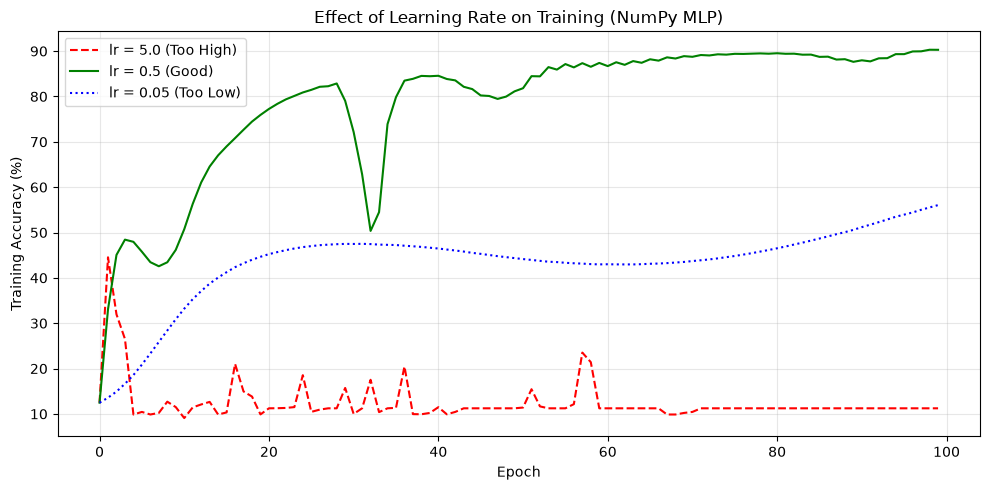


Observation: lr=5.0 may oscillate or converge faster but unstably.
lr=0.05 learns correctly but much more slowly — would need 500+ epochs.


In [16]:
import matplotlib.pyplot as plt

def train_numpy_with_lr(learning_rate, epochs=100):
    """Train the NumPy MLP with a given learning rate and track accuracy."""
    # Fresh weights for each experiment
    np.random.seed(42)
    W1_ = np.random.randn(784, 128) * 0.01
    b1_ = np.zeros((1, 128))
    W2_ = np.random.randn(128, 10) * 0.01
    b2_ = np.zeros((1, 10))
    
    accuracy_log = []
    
    for i in range(epochs):
        Z1_, A1_, Z2_, A2_ = forward_propagation(X_train, W1_, b1_, W2_, b2_)
        dW1_, db1_, dW2_, db2_ = backward_propagation(X_train, Y_train, Z1_, A1_, A2_, W2_)
        
        # Gradient descent step
        W1_ -= learning_rate * dW1_
        b1_ -= learning_rate * db1_
        W2_ -= learning_rate * dW2_
        b2_ -= learning_rate * db2_
        
        preds = np.argmax(A2_, axis=1)
        acc = get_accuracy(preds, Y_train_raw)
        accuracy_log.append(acc)
    
    return accuracy_log

# Run the same training with three different learning rates
print("Running learning rate experiment (this may take ~30 seconds)...")
acc_high   = train_numpy_with_lr(learning_rate=5.0)   # Too high — may oscillate
acc_good   = train_numpy_with_lr(learning_rate=0.5)   # Baseline (what we used)
acc_low    = train_numpy_with_lr(learning_rate=0.05)  # Too low — slow learning

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(acc_high, label='lr = 5.0 (Too High)',  color='red',   linestyle='--')
plt.plot(acc_good, label='lr = 0.5 (Good)',       color='green', linestyle='-')
plt.plot(acc_low,  label='lr = 0.05 (Too Low)',   color='blue',  linestyle=':')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.title('Effect of Learning Rate on Training (NumPy MLP)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: lr=5.0 may oscillate or converge faster but unstably.")
print("lr=0.05 learns correctly but much more slowly — would need 500+ epochs.")

---
## Section 4: Introduction to Recurrent Neural Networks (RNNs)

MLPs and CNNs process **one fixed-size input** at a time. But what about **sequences** — data where the order matters, like time series, sentences, or speech?

For that, we use **Recurrent Neural Networks (RNNs)**.

### How an RNN Works

An RNN processes a sequence **one step at a time** and maintains a **hidden state** — a memory vector that carries information from previous steps into the current one:

```
Input:      x₁  →  x₂  →  x₃  →  x₄
              ↓      ↓      ↓      ↓
Hidden:     h₁  →  h₂  →  h₃  →  h₄  →  output
            (memory carries context forward)
```

At each step `t`:
$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b)$$

- `h_{t-1}` = memory from the previous step
- `x_t` = current input
- `tanh` = activation that keeps values in [-1, 1], preventing blow-up

### Toy Example: Predicting the Next Digit in a Sequence

Let's train a tiny RNN on a simple sequence task: given a sequence like `[1, 2, 3, 4]`, predict the next digit. This mimics how language models predict the next word.

> **Note:** This is a simplified, self-contained RNN demo. In practice, **LSTMs** (Long Short-Term Memory) and **GRUs** are used instead of plain RNNs because they handle long sequences without the gradient vanishing over many steps.

In [17]:
import torch
import torch.nn as nn

class SimpleRNN(nn.Module):
    """A minimal RNN for sequence prediction."""
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        
        # PyTorch's built-in RNN handles the recurrent loop for us
        # batch_first=True means our tensors are shaped (batch, sequence, features)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        
        # Fully connected layer maps the final hidden state to a class prediction
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # h0: initial hidden state — all zeros (no prior memory)
        # Shape: (num_layers=1, batch_size, hidden_size)
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        
        # RNN processes the full sequence and returns:
        #   out: output at every time step (batch, seq_len, hidden_size)
        #   hn:  final hidden state (memory after seeing the whole sequence)
        out, hn = self.rnn(x, h0)
        
        # We only care about the LAST time step's output (the final prediction)
        out = self.fc(out[:, -1, :])  # out[:, -1, :] → last time step for each batch
        return out

# ─── Create a toy sequence dataset ───
# Sequences of 4 consecutive digits (0–8), predict the 5th
# Each digit is represented as a 1D feature
sequences = []
targets   = []

for start in range(0, 50):  # 50 training sequences
    seq = [(start + i) % 10 for i in range(4)]  # e.g., [3, 4, 5, 6]
    target = (start + 4) % 10                    # next digit: 7
    sequences.append(seq)
    targets.append(target)

# Convert to tensors: sequences shape (50, 4, 1) — 50 examples, 4 steps, 1 feature
X_seq = torch.tensor(sequences, dtype=torch.float32).unsqueeze(-1) / 9.0  # Normalise to [0,1]
Y_seq = torch.tensor(targets,   dtype=torch.long)

print(f"Sequence data shape: {X_seq.shape}")
print(f"Target shape: {Y_seq.shape}")
print(f"Example: input {sequences[0]} → predict {targets[0]}")

# ─── Train the RNN ───
rnn_model     = SimpleRNN(input_size=1, hidden_size=32, output_size=10)
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.01)
rnn_criterion = nn.CrossEntropyLoss()

print("\nTraining the RNN...")
for epoch in range(200):
    rnn_model.train()
    rnn_optimizer.zero_grad()
    outputs = rnn_model(X_seq)
    loss    = rnn_criterion(outputs, Y_seq)
    loss.backward()
    rnn_optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss.item():.4f}")

# ─── Test the RNN ───
rnn_model.eval()
with torch.no_grad():
    test_seq   = torch.tensor([[[5/9], [6/9], [7/9], [8/9]]])  # Sequence: 5,6,7,8 → predict 9
    pred       = rnn_model(test_seq)
    predicted_digit = torch.argmax(pred, dim=1).item()
    print(f"\nTest: Input sequence [5, 6, 7, 8] → Predicted next digit: {predicted_digit} (correct: 9)")

Sequence data shape: torch.Size([50, 4, 1])
Target shape: torch.Size([50])
Example: input [0, 1, 2, 3] → predict 4

Training the RNN...
Epoch   0 | Loss: 2.3384
Epoch  50 | Loss: 0.2323
Epoch 100 | Loss: 0.0166
Epoch 150 | Loss: 0.0060

Test: Input sequence [5, 6, 7, 8] → Predicted next digit: 9 (correct: 9)


---
## Interactive Demo: Draw a Digit!

This is the **'App'** part of our Digit Recognition App. The cell below creates an interactive widget where you can draw a digit with your mouse and see the CNN predict it in real time.

**How it works:**
1. Draw on the canvas (white strokes on black background)
2. Click **Predict** to feed your drawing to the trained CNN
3. See the predicted digit and a bar chart of all 10 class probabilities

> **Requirements:** This requires `ipywidgets`. If it's not installed, run: `pip install ipywidgets` in your terminal.

In [18]:
from ipycanvas import Canvas
from ipywidgets import widgets, HBox, VBox
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import torch

# ─── True Drawing Canvas ───
# We use a native 28x28 grid, but display it at 280x280 so it's easy to draw on
GRID_SIZE = 28

# This numpy array tracks the math in the background instantly
drawing_state = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)

# The visual canvas
canvas = Canvas(width=GRID_SIZE, height=GRID_SIZE)
canvas.layout.width = '280px'
canvas.layout.height = '280px'

# Fill with black
canvas.fill_style = 'black'
canvas.fill_rect(0, 0, GRID_SIZE, GRID_SIZE)

is_drawing = False

def paint(x, y):
    """Draws on the visual canvas AND updates the numpy array instantly."""
    ix, iy = int(x), int(y)
    
    # Create a small "brush" so the line isn't too thin
    # We color the center pixel and its immediate neighbors (a plus shape)
    brush_pixels = [(ix, iy), (ix+1, iy), (ix-1, iy), (ix, iy+1), (ix, iy-1)]
    
    canvas.fill_style = 'white'
    for px, py in brush_pixels:
        if 0 <= px < GRID_SIZE and 0 <= py < GRID_SIZE:
            drawing_state[py, px] = 1.0  # Update Python math (Note: array is [y, x])
            canvas.fill_rect(px, py, 1, 1) # Update visual screen

def on_mouse_down(x, y):
    global is_drawing
    is_drawing = True
    paint(x, y)

def on_mouse_move(x, y):
    if is_drawing:
        paint(x, y)

def on_mouse_up(x, y):
    global is_drawing
    is_drawing = False

# Attach the mouse events
canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)
canvas.on_mouse_out(on_mouse_up) # Stop drawing if mouse leaves the square

# UI Controls
output_label  = widgets.Label(value="Draw a digit IN THE CENTER, then click Predict!")
predict_btn   = widgets.Button(description='Predict', button_style='success')
clear_btn     = widgets.Button(description='Clear',   button_style='warning')
output_widget = widgets.Output()

def on_predict(b):
    with output_widget:
        output_widget.clear_output(wait=True)
        
        # We already have the perfect 28x28 array stored in drawing_state!
        img_array = drawing_state.copy()
        
        # Convert to PyTorch tensor: (1, 1, 28, 28)
        tensor = torch.tensor(img_array, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        
        # Run inference
        loaded_cnn.eval()
        with torch.no_grad():
            logits = loaded_cnn(tensor)
            probs  = torch.softmax(logits, dim=1).squeeze().numpy()
            pred   = int(np.argmax(probs))
        
        output_label.value = f"Predicted Digit: {pred}  (confidence: {probs[pred]*100:.1f}%)"
        
        # Show probability bar chart
        fig, axes = plt.subplots(1, 2, figsize=(9, 3))
        
        axes[0].imshow(img_array, cmap='gray')
        axes[0].set_title("What the CNN sees")
        axes[0].axis('off')
        
        bars = axes[1].bar(range(10), probs, color=['green' if i == pred else 'steelblue' for i in range(10)])
        axes[1].set_xticks(range(10))
        axes[1].set_xlabel('Digit Class')
        axes[1].set_ylabel('Probability')
        axes[1].set_title(f'CNN Probabilities — Prediction: {pred}')
        axes[1].set_ylim(0, 1)
        
        plt.tight_layout()
        plt.show()

def on_clear(b):
    """Reset everything to black/zeros."""
    global drawing_state
    drawing_state[:] = 0.0
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, GRID_SIZE, GRID_SIZE)
    output_label.value = "Canvas cleared! Draw a new digit."
    with output_widget:
        output_widget.clear_output()

predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)

controls = HBox([predict_btn, clear_btn])

print("\nInstructions: CLICK AND DRAG inside the black square to draw your digit naturally!")
display(VBox([canvas, controls, output_label, output_widget]))


Instructions: CLICK AND DRAG inside the black square to draw your digit naturally!
